
# DIP + POCS-Style Seismic Interpolation Workflow for SWAN

This notebook is a complete runnable example of a hybrid interpolation workflow that combines:

- POCS-style sparse-domain reconstruction
- Deep Image Prior (DIP) refinement
- strict data consistency on observed traces

It assumes:

```python
patches.shape == (nsample, 128, 128)
```

so each sample is a 2D seismic patch of shape `(128, 128)`.



## Background

A POCS-style interpolation workflow alternates between a structured/sparse projection and a data-consistency projection. Sparse transform domains commonly used for seismic interpolation include Fourier and related transforms. citeturn835229search7turn822048search17

Deep Image Prior (DIP) uses a randomly initialized convolutional generator as an implicit prior, optimized on a single corrupted image without external training data. Early stopping matters because the network can eventually fit corruption. citeturn822048search0turn822048search24

A 2020 SEG abstract explicitly reported “seismic data interpolation using a POCS-guided deep image prior.” citeturn835229search5


In [1]:

# ============================================================
# 0. Imports and configuration
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

SWAN_FILE = "../dataset/SWAN_syn_poststack.npz"   # change if needed
SAMPLE_INDEX = 0

MISSING_RATE = 0.60
SEED = 1234

POCS_ITERS = 80
POCS_KEEP_START = 0.08
POCS_KEEP_END = 0.35

DIP_INNER_STEPS = 250
OUTER_ITERS = 4
LR = 1e-3
LAMBDA_MISSING = 0.25
TV_WEIGHT = 1e-5
NOISE_STD = 1.0 / 30.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Using device:", DEVICE)


Using device: cuda



## 1. Load one SWAN sample

If the SWAN file is not found, the notebook falls back to a synthetic seismic-style sample so the example remains runnable.


Source: SWAN sample 0 from ../dataset/SWAN_syn_poststack.npz
Shape : (128, 128)


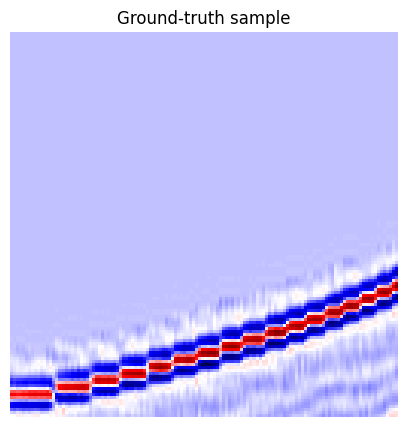

In [2]:

# ============================================================
# 1. Data loading
# ============================================================
def make_synthetic_seismic(nx=128, nt=128):
    t = np.arange(nt)
    x = np.arange(nx)
    X, T = np.meshgrid(x, t)
    img = np.zeros((nt, nx), dtype=np.float32)

    event_times = [
        18 + 0.22 * X,
        40 + 0.10 * X + 0.002 * (X - 64) ** 2,
        65 - 0.12 * X + 0.0015 * (X - 30) ** 2,
        90 + 0.06 * X
    ]
    for k, tau in enumerate(event_times):
        amp = 1.0 - 0.15 * k
        sigma = 1.8 + 0.5 * k
        img += amp * np.exp(-0.5 * ((T - tau) / sigma) ** 2)

    fault_col = 78
    shifted = img.copy()
    shifted[:, fault_col:] = np.roll(shifted[:, fault_col:], shift=5, axis=0)
    img = 0.7 * img + 0.3 * shifted

    wave = np.cos(0.40 * T) * np.exp(-((T - 64) / 90) ** 2)
    img = img * wave

    img2 = img.copy()
    img2[1:-1, 1:-1] = (
        img[:-2, 1:-1] + img[2:, 1:-1] + img[1:-1, :-2] + img[1:-1, 2:] + 4 * img[1:-1, 1:-1]
    ) / 8.0
    img = img2

    img -= img.mean()
    img /= (img.std() + 1e-8)
    return img.astype(np.float32)

def load_swan_sample(filename, sample_index=0):
    data = np.load(filename, mmap_mode="r")
    patches = data["patches"]
    sample = np.asarray(patches[sample_index], dtype=np.float32)
    return sample

if os.path.exists(SWAN_FILE):
    x_true = load_swan_sample(SWAN_FILE, SAMPLE_INDEX)
    source_name = f"SWAN sample {SAMPLE_INDEX} from {SWAN_FILE}"
else:
    x_true = make_synthetic_seismic()
    source_name = "synthetic fallback sample"

x_true -= x_true.mean()
x_true /= (x_true.std() + 1e-8)

print("Source:", source_name)
print("Shape :", x_true.shape)

plt.figure(figsize=(5, 5))
plt.imshow(x_true, cmap="seismic", aspect="auto")
plt.title("Ground-truth sample")
plt.axis("off")
plt.show()


## 2. Create a missing-trace mask

Observed fraction: 0.406


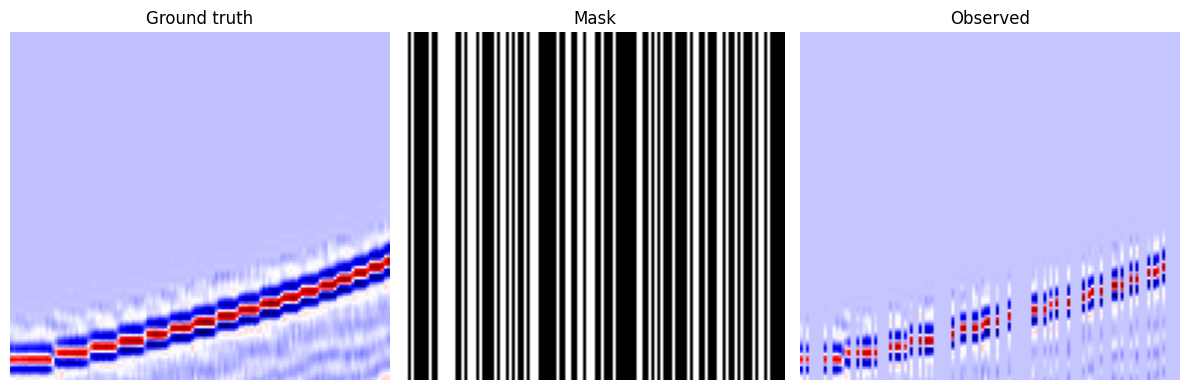

In [3]:

# ============================================================
# 2. Mask generation
# ============================================================
def make_column_mask(shape, missing_rate=0.5, seed=0):
    nt, nx = shape
    rng = np.random.default_rng(seed)
    keep_cols = rng.random(nx) > missing_rate
    if keep_cols.sum() < max(4, nx // 16):
        idx = rng.choice(nx, size=max(4, nx // 16), replace=False)
        keep_cols[:] = False
        keep_cols[idx] = True
    mask = np.tile(keep_cols[None, :], (nt, 1)).astype(np.float32)
    return mask

mask = make_column_mask(x_true.shape, missing_rate=MISSING_RATE, seed=SEED)
y_obs = mask * x_true

print(f"Observed fraction: {mask.mean():.3f}")

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(x_true, cmap="seismic", aspect="auto")
axs[0].set_title("Ground truth"); axs[0].axis("off")
axs[1].imshow(mask, cmap="gray", aspect="auto", vmin=0, vmax=1)
axs[1].set_title("Mask"); axs[1].axis("off")
axs[2].imshow(y_obs, cmap="seismic", aspect="auto")
axs[2].set_title("Observed"); axs[2].axis("off")
plt.tight_layout(); plt.show()


## 3. Metrics

In [4]:

# ============================================================
# 3. Metrics
# ============================================================
def rmse(x, y):
    return float(np.sqrt(np.mean((x - y) ** 2)))

def snr_db(x_true, x_est):
    num = np.sum(x_true ** 2)
    den = np.sum((x_true - x_est) ** 2) + 1e-12
    return float(10.0 * np.log10(num / den))

def psnr(x_true, x_est):
    mse = np.mean((x_true - x_est) ** 2)
    peak = np.max(np.abs(x_true))
    return float(20.0 * np.log10(peak / (np.sqrt(mse) + 1e-12)))

print("Masked observation:")
print("  RMSE =", rmse(x_true, y_obs))
print("  SNR  =", snr_db(x_true, y_obs))
print("  PSNR =", psnr(x_true, y_obs))


Masked observation:
  RMSE = 0.7761579751968384
  SNR  = 2.2009966373443604
  PSNR = 19.4542236328125


## 4. POCS-style interpolation in the f-k domain

In [5]:

# ============================================================
# 4. POCS-style FK interpolation
# ============================================================
def enforce_data_consistency(x, y_obs, mask):
    return mask * y_obs + (1.0 - mask) * x

def hard_threshold_topk_complex(F, keep_fraction):
    keep_fraction = float(np.clip(keep_fraction, 1e-6, 1.0))
    mag = np.abs(F).reshape(-1)
    k = max(1, int(np.ceil(keep_fraction * mag.size)))
    if k >= mag.size:
        return F
    thresh = np.partition(mag, -k)[-k]
    out = F.copy()
    out[np.abs(out) < thresh] = 0.0
    return out

def pocs_fk(y_obs, mask, niter=60, keep_start=0.05, keep_end=0.30):
    x = y_obs.copy().astype(np.float32)
    for it in range(niter):
        alpha = it / max(1, niter - 1)
        keep = (1 - alpha) * keep_start + alpha * keep_end
        F = np.fft.fft2(x)
        F = hard_threshold_topk_complex(F, keep)
        x = np.real(np.fft.ifft2(F)).astype(np.float32)
        x = enforce_data_consistency(x, y_obs, mask)
    return x

x_pocs = pocs_fk(y_obs, mask, niter=POCS_ITERS, keep_start=POCS_KEEP_START, keep_end=POCS_KEEP_END)

print("POCS-only result:")
print("  RMSE =", rmse(x_true, x_pocs))
print("  SNR  =", snr_db(x_true, x_pocs))
print("  PSNR =", psnr(x_true, x_pocs))


POCS-only result:
  RMSE = 0.728413462638855
  SNR  = 2.7524397373199463
  PSNR = 20.005666732788086


## 5. DIP network

In [6]:

# ============================================================
# 5. DIP network
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class SmallUNet(nn.Module):
    def __init__(self, in_ch=8, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.AvgPool2d(2)
        self.enc2 = ConvBlock(base, base * 2)
        self.pool2 = nn.AvgPool2d(2)
        self.bottleneck = ConvBlock(base * 2, base * 4)
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = ConvBlock(base * 4 + base * 2, base * 2)
        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = ConvBlock(base * 2 + base, base)
        self.final = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final(d1)

def total_variation(x):
    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    return dx.abs().mean() + dy.abs().mean()

def to_torch_image(x):
    return torch.from_numpy(x).float()[None, None]


## 6. DIP refinement block

In [7]:

# ============================================================
# 6. DIP refinement
# ============================================================
def dip_refine_with_pseudo_target(y_obs, mask, x_pseudo, inner_steps=300, lr=1e-3,
                                  lambda_missing=0.2, tv_weight=1e-5, noise_std=1/30,
                                  device="cpu"):
    nt, nx = y_obs.shape
    net = SmallUNet(in_ch=8, base=32).to(device)

    z = torch.randn(1, 8, nt, nx, device=device)
    y_t = to_torch_image(y_obs).to(device)
    m_t = to_torch_image(mask).to(device)
    pseudo_t = to_torch_image(x_pseudo).to(device)

    opt = torch.optim.Adam(net.parameters(), lr=lr)

    best_loss = float("inf")
    best_out = None

    for step in range(inner_steps):
        z_in = z + noise_std * torch.randn_like(z)
        x_net = net(z_in)

        loss_obs = ((m_t * x_net - m_t * y_t) ** 2).mean()
        loss_missing = (((1.0 - m_t) * (x_net - pseudo_t)) ** 2).mean()
        loss_tv = total_variation(x_net)

        loss = loss_obs + lambda_missing * loss_missing + tv_weight * loss_tv

        opt.zero_grad()
        loss.backward()
        opt.step()

        if loss.item() < best_loss:
            best_loss = float(loss.item())
            best_out = x_net.detach().cpu().numpy()[0, 0]

    x_out = enforce_data_consistency(best_out.astype(np.float32), y_obs, mask)
    return x_out, best_loss


## 7. Alternating DIP + POCS workflow

In [8]:

# ============================================================
# 7. Hybrid DIP + POCS
# ============================================================
def dip_pocs_interpolation(y_obs, mask,
                           outer_iters=20,
                           pocs_iters=40,
                           pocs_keep_start=0.08,
                           pocs_keep_end=0.35,
                           dip_inner_steps=250,
                           lr=1e-3,
                           lambda_missing=0.25,
                           tv_weight=1e-5,
                           noise_std=1/30,
                           device="cpu"):
    x = y_obs.copy().astype(np.float32)
    history = []

    for outer in range(outer_iters):
        x_pocs = pocs_fk(
            x, mask,
            niter=pocs_iters,
            keep_start=pocs_keep_start,
            keep_end=pocs_keep_end
        )

        x_dip, dip_loss = dip_refine_with_pseudo_target(
            y_obs=y_obs,
            mask=mask,
            x_pseudo=x_pocs,
            inner_steps=dip_inner_steps,
            lr=lr,
            lambda_missing=lambda_missing,
            tv_weight=tv_weight,
            noise_std=noise_std,
            device=device
        )

        x = enforce_data_consistency(x_dip, y_obs, mask)
        history.append({"outer_iter": outer + 1, "dip_loss": dip_loss})
        print(f"Outer iteration {outer+1}/{outer_iters} done. DIP loss = {dip_loss:.6e}")

    return x, history

x_hybrid, history = dip_pocs_interpolation(
    y_obs=y_obs,
    mask=mask,
    outer_iters=OUTER_ITERS,
    pocs_iters=max(20, POCS_ITERS // 2),
    pocs_keep_start=POCS_KEEP_START,
    pocs_keep_end=POCS_KEEP_END,
    dip_inner_steps=DIP_INNER_STEPS,
    lr=LR,
    lambda_missing=LAMBDA_MISSING,
    tv_weight=TV_WEIGHT,
    noise_std=NOISE_STD,
    device=DEVICE
)

print("\nHybrid DIP+POCS result:")
print("  RMSE =", rmse(x_true, x_hybrid))
print("  SNR  =", snr_db(x_true, x_hybrid))
print("  PSNR =", psnr(x_true, x_hybrid))


Outer iteration 1/4 done. DIP loss = 6.639741e-02
Outer iteration 2/4 done. DIP loss = 1.736147e-02
Outer iteration 3/4 done. DIP loss = 1.315512e-02
Outer iteration 4/4 done. DIP loss = 9.496441e-03

Hybrid DIP+POCS result:
  RMSE = 0.35422080755233765
  SNR  = 9.014517784118652
  PSNR = 26.26774787902832


## 8. Visual comparison

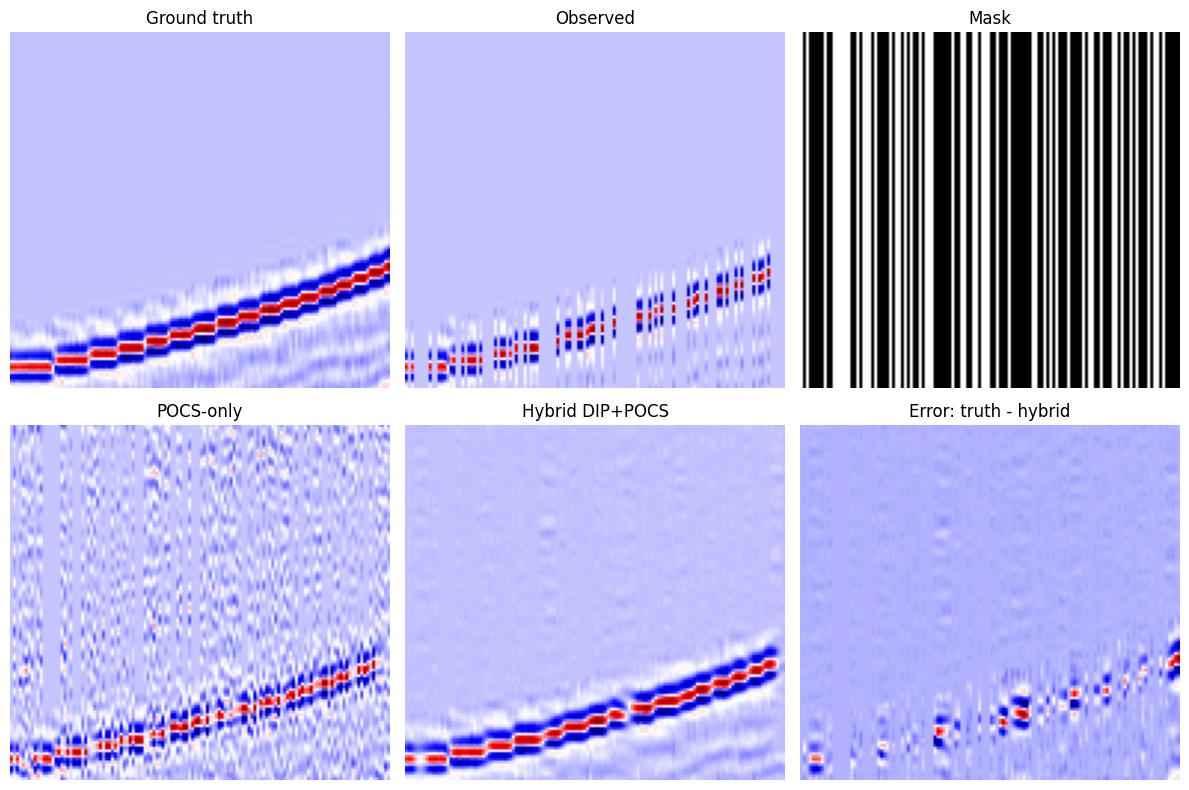

In [9]:

# ============================================================
# 8. Visual comparison
# ============================================================
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

axs[0, 0].imshow(x_true, cmap="seismic", aspect="auto")
axs[0, 0].set_title("Ground truth"); axs[0, 0].axis("off")

axs[0, 1].imshow(y_obs, cmap="seismic", aspect="auto")
axs[0, 1].set_title("Observed"); axs[0, 1].axis("off")

axs[0, 2].imshow(mask, cmap="gray", aspect="auto", vmin=0, vmax=1)
axs[0, 2].set_title("Mask"); axs[0, 2].axis("off")

axs[1, 0].imshow(x_pocs, cmap="seismic", aspect="auto")
axs[1, 0].set_title("POCS-only"); axs[1, 0].axis("off")

axs[1, 1].imshow(x_hybrid, cmap="seismic", aspect="auto")
axs[1, 1].set_title("Hybrid DIP+POCS"); axs[1, 1].axis("off")

axs[1, 2].imshow(x_true - x_hybrid, cmap="seismic", aspect="auto")
axs[1, 2].set_title("Error: truth - hybrid"); axs[1, 2].axis("off")

plt.tight_layout()
plt.show()


## 9. Numerical comparison

In [10]:

# ============================================================
# 9. Numerical comparison
# ============================================================
results = {
    "Masked observed": {
        "RMSE": rmse(x_true, y_obs),
        "SNR (dB)": snr_db(x_true, y_obs),
        "PSNR (dB)": psnr(x_true, y_obs),
    },
    "POCS only": {
        "RMSE": rmse(x_true, x_pocs),
        "SNR (dB)": snr_db(x_true, x_pocs),
        "PSNR (dB)": psnr(x_true, x_pocs),
    },
    "Hybrid DIP+POCS": {
        "RMSE": rmse(x_true, x_hybrid),
        "SNR (dB)": snr_db(x_true, x_hybrid),
        "PSNR (dB)": psnr(x_true, x_hybrid),
    },
}

for name, vals in results.items():
    print(name)
    for k, v in vals.items():
        print(f"  {k:10s}: {v:.4f}")
    print()


Masked observed
  RMSE      : 0.7762
  SNR (dB)  : 2.2010
  PSNR (dB) : 19.4542

POCS only
  RMSE      : 0.7284
  SNR (dB)  : 2.7524
  PSNR (dB) : 20.0057

Hybrid DIP+POCS
  RMSE      : 0.3542
  SNR (dB)  : 9.0145
  PSNR (dB) : 26.2677




## 10. How to adapt this to SWAN at scale

To turn this into a larger SWAN experiment:

- loop over many `sample_index` values
- test random, periodic, and burst-gap masks
- replace the Fourier-domain thresholding with wavelet/curvelet/seislet/rank-reduction operators
- compare pure POCS, pure DIP, and POCS-guided DIP
- evaluate synthetic SWAN and real SWAN separately

This notebook is intentionally compact and didactic rather than highly optimized.
